# Task 1 — Exploratory Data Analysis
**Dataset:** MachineLearningRating_v3.txt (~1 million rows, 52 columns)  
**Goal:** Assess data quality and uncover initial patterns in risk and profitability.

**Sections**
1. Setup & Load
2. Data Summarization — descriptive stats & dtype review
3. Data Quality Assessment — missing values & handling strategy
4. Univariate Analysis — histograms & bar charts
5. Bivariate & Multivariate Analysis — scatter, correlations
6. Geographic Trends — premium, cover type, make by province
7. Outlier Detection — box plots & IQR table

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

from src.data_loader import load_data, summarize_data, compute_loss_ratio, flag_high_missing
from src.eda_utils import (
    descriptive_stats, dtype_review,
    missing_summary_table,
    plot_numeric_distributions, plot_categorical_counts,
    loss_ratio_by_group, plot_loss_ratio_by_group,
    correlation_heatmap,
    plot_monthly_trend,
    outlier_summary, plot_boxplots,
    scatter_premium_vs_claims,
    premium_by_province, cover_type_by_province, top_makes_by_province,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data

In [2]:
df = load_data("../data/MachineLearningRating_v3.txt")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 1,000,098 rows x 52 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000


---
## 2. Data Summarization

### 2.1 Descriptive Statistics — All Numerical Features

In [3]:
descriptive_stats(df)

,UnderwrittenCoverID,PolicyID,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,CapitalOutstanding,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1000098.0000,1000098.0000,1000098.0000,999546.0000,999546.0000,999546.0000,999546.0000,220456.0000,1000096.0000,0.0000,1000098.0000,1000098.0000,1000098.0000,1000098.0000
mean,104817.5461,7956.6825,2010.2254,4.0466,2466.7433,97.2079,4.0192,225531.1299,52678.6071,<NA>,604172.7326,117.8757,61.9055,64.8612
std,63293.7085,5290.0385,3.2614,0.2940,442.8006,19.3933,0.4683,564515.7498,111474.8707,<NA>,1508331.8380,399.7017,230.2845,2384.0747
min,1.0000,14.0000,1987.0000,0.0000,0.0000,0.0000,0.0000,20000.0000,-2.0000,<NA>,0.0100,0.0000,-782.5768,-12002.4123
25%,55143.0000,4500.0000,2008.0000,4.0000,2237.0000,75.0000,4.0000,135000.0000,0.0000,<NA>,5000.0000,3.2248,0.0000,0.0000
50%,94083.0000,7071.0000,2011.0000,4.0000,2694.0000,111.0000,4.0000,220000.0000,0.0000,<NA>,7500.0000,8.4369,2.1783,0.0000
75%,139190.0000,11077.0000,2013.0000,4.0000,2694.0000,111.0000,4.0000,280000.0000,0.0000,<NA>,250000.0000,90.0000,21.9298,0.0000
max,301175.0000,23246.0000,2015.0000,10.0000,12880.0000,309.0000,6.0000,26550000.0000,700000.0000,<NA>,12636200.0000,74422.1679,65282.6034,393092.1053
skewness,0.6117,0.7374,-0.7945,5.7046,3.5760,0.2447,-2.5313,40.8705,2.0125,<NA>,2.5486,122.9746,138.5965,69.9331
kurtosis,0.0288,0.2820,0.6081,71.2853,102.2898,3.0100,18.8338,1762.3216,3.2508,<NA>,4.6452,22210.7017,37176.1855,6791.9262


### 2.2 Financial Columns Close-up

Focus on , , and related columns that drive risk modelling.

In [4]:
financial_cols = ["TotalPremium", "TotalClaims", "SumInsured",
                  "CalculatedPremiumPerTerm", "CapitalOutstanding"]
df[financial_cols].describe().T.assign(
    zeros=(df[financial_cols] == 0).sum(),
    zeros_pct=(df[financial_cols] == 0).mean().mul(100).round(2),
    skewness=df[financial_cols].skew(),
)

,count,mean,std,min,25%,50%,75%,max,zeros,zeros_pct,skewness
TotalPremium,1000098.0000,61.9055,230.2845,-782.5768,0.0000,2.1783,21.9298,65282.6034,381634,38.1600,138.5965
TotalClaims,1000098.0000,64.8612,2384.0747,-12002.4123,0.0000,0.0000,0.0000,393092.1053,997305,99.7200,69.9331
SumInsured,1000098.0000,604172.7326,1508331.8380,0.0100,5000.0000,7500.0000,250000.0000,12636200.0000,0,0.0000,2.5486
CalculatedPremiumPerTerm,1000098.0000,117.8757,399.7017,0.0000,3.2248,8.4369,90.0000,74422.1679,7,0.0000,122.9746
CapitalOutstanding,1000096.0000,52678.6071,111474.8707,-2.0000,0.0000,0.0000,0.0000,700000.0000,792780,79.2700,2.0125


**Observations**
-  is 99.7% zero — zero-inflated distribution typical of insurance portfolios.
-  is 38.2% zero — warrants investigation (possible data entry or zero-premium add-ons).
- Both columns show extreme positive skewness; a log transform will be required for modelling.

### 2.3 Dtype Review

In [5]:
review = dtype_review(df)
review

,stored_dtype,semantic_type,flag
column,,,
UnderwrittenCoverID,Int64,numerical,
PolicyID,Int64,numerical,
TransactionMonth,datetime64[ns],datetime,
IsVATRegistered,bool,boolean,
Citizenship,object,categorical,
LegalType,object,categorical,
Title,object,categorical,
Language,object,categorical,
Bank,object,categorical,


In [6]:
flagged = review[review["flag"] != ""]
print(f"{len(flagged)} columns flagged:")
flagged

4 columns flagged:


,stored_dtype,semantic_type,flag
column,,,
PostalCode,object,categorical,>90% values numeric but stored as object
mmcode,object,categorical,>90% values numeric but stored as object
VehicleIntroDate,object,categorical,may be datetime — consider pd.to_datetime
NumberOfVehiclesInFleet,Int64,numerical,looks boolean — consider casting


**Dtype corrections needed**

| Column | Issue | Recommended action |
|---|---|---|
|  | Stored as object, >90% numeric | Cast to  or keep as string category |
|  | Stored as object, >90% numeric | Cast to  |
|  | Date string () | Parse with  |
|  | All null — looks boolean | Drop or investigate source |

---
## 3. Data Quality Assessment

### 3.1 Missing Values

In [7]:
summary = summarize_data(df)
print(f"Total rows            : {summary['shape'][0]:,}")
print(f"Total columns         : {summary['shape'][1]}")
print(f"Duplicate rows        : {summary['duplicate_rows']:,}")
print(f"Columns with any null : {sum(v > 0 for v in summary['null_counts'].values())} of {summary['shape'][1]}")

Total rows            : 1,000,098
Total columns         : 52
Duplicate rows        : 74
Columns with any null : 22 of 52


In [8]:
missing_summary_table(df)

,missing_count,missing_pct
WrittenOff,1000098,100.0000
NewVehicle,1000098,100.0000
CrossBorder,1000098,100.0000
NumberOfVehiclesInFleet,1000098,100.0000
Converted,1000098,100.0000
Rebuilt,1000098,100.0000
CustomValueEstimate,779642,77.9600
Bank,145961,14.5900
AccountType,40232,4.0200
Gender,9536,0.9500


Columns with >5% missing: ['Bank', 'CustomValueEstimate', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']


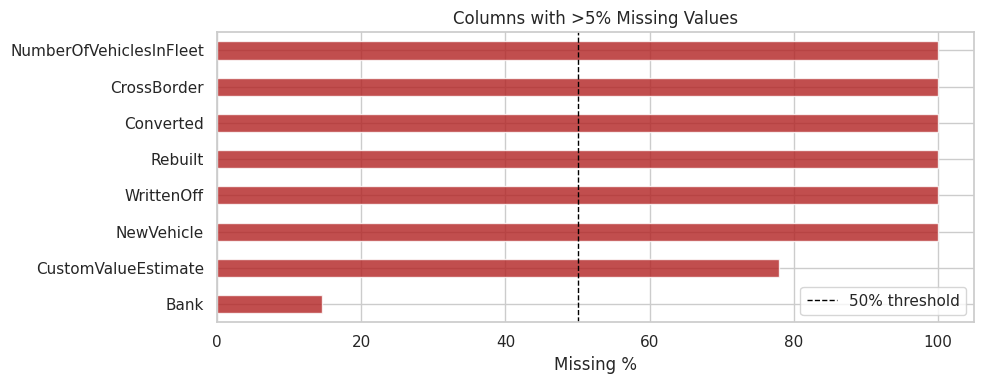

In [9]:
# Visualise missing-value pattern for high-missing columns
high_missing_cols = flag_high_missing(df, threshold=0.05)
print("Columns with >5% missing:", high_missing_cols)

fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = df[high_missing_cols].isnull().mean().sort_values() * 100
missing_pct.plot(kind="barh", ax=ax, color="firebrick", alpha=0.8)
ax.axvline(50, color="black", linestyle="--", linewidth=1, label="50% threshold")
ax.set_xlabel("Missing %")
ax.set_title("Columns with >5% Missing Values")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Handling Strategy

| Column(s) | Missing % | Strategy |
|---|---|---|
| , , , , ,  | 100% | **Drop** — no information content |
|  | ~78% | **Drop** for modelling; use only where available for EDA |
| ,  | 4–15% | **Impute** with mode or "Unknown" category |
| ,  | <1% | **Impute** with mode or "Not specified" |
| , , , , etc. | 0.06% | **Drop rows** (552 rows, <0.1% of data) |
|  | 0.0002% | **Drop 2 rows** |

In [10]:
# Apply the documented strategy
DROP_COLS = ["CrossBorder", "NewVehicle", "WrittenOff", "Rebuilt",
             "Converted", "NumberOfVehiclesInFleet", "CustomValueEstimate"]
df_clean = df.drop(columns=DROP_COLS)

# Fill low-missing categoricals
for col in ["Bank", "AccountType", "Gender", "MaritalStatus"]:
    df_clean[col] = df_clean[col].fillna("Not specified")

# Drop the 552 rows missing vehicle attributes
vehicle_cols = ["mmcode", "VehicleType", "make", "Model",
                "VehicleIntroDate", "NumberOfDoors", "bodytype",
                "kilowatts", "cubiccapacity", "Cylinders"]
before = len(df_clean)
df_clean = df_clean.dropna(subset=vehicle_cols)
df_clean = df_clean.dropna(subset=["CapitalOutstanding"])
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {len(df_clean):,}")
print(f"Remaining nulls      : {df_clean.isnull().sum().sum()}")
df_clean["LossRatio"] = compute_loss_ratio(df_clean)

Rows before cleaning : 1,000,098
Rows after cleaning  : 999,544


Remaining nulls      : 0


---
## 4. Univariate Analysis

### 4.1 Numerical Columns — Histograms

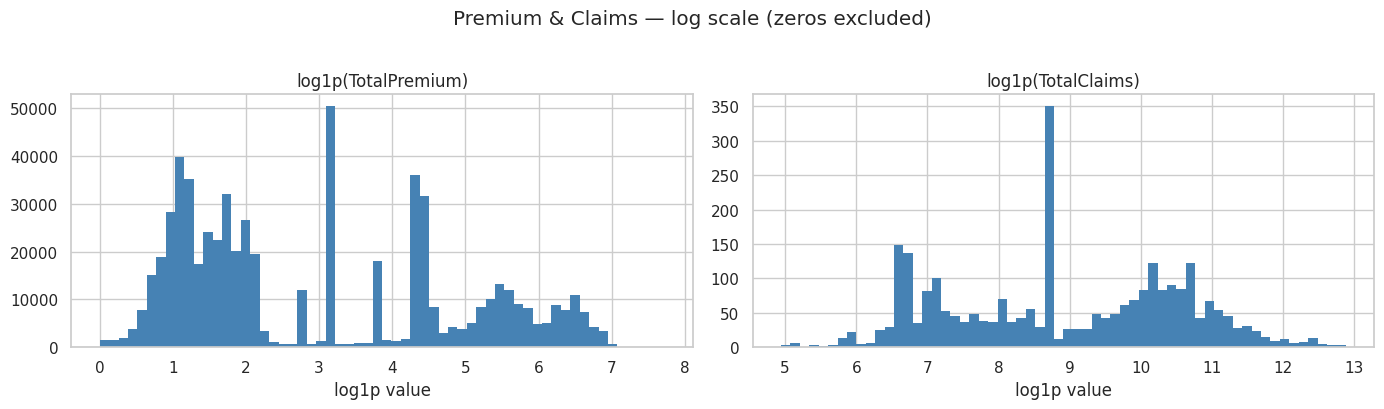

In [11]:
# Log-scale histograms for heavily skewed financial columns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["TotalPremium", "TotalClaims"]):
    vals = df_clean[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=60, color="steelblue", edgecolor="none")
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p value")
fig.suptitle("Premium & Claims — log scale (zeros excluded)", y=1.02)
fig.tight_layout()
plt.show()

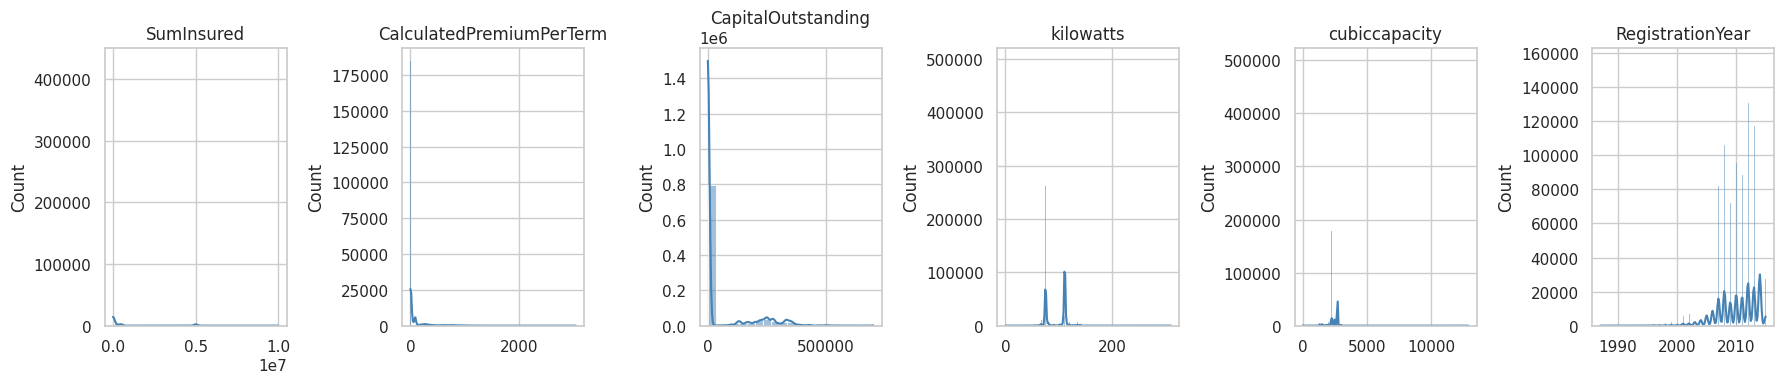

In [12]:
# Vehicle & policy numerical columns
plot_numeric_distributions(
    df_clean,
    ["SumInsured", "CalculatedPremiumPerTerm",
     "CapitalOutstanding", "kilowatts", "cubiccapacity", "RegistrationYear"],
    figsize=(18, 4)
)
plt.show()

### 4.2 Categorical Columns — Bar Charts

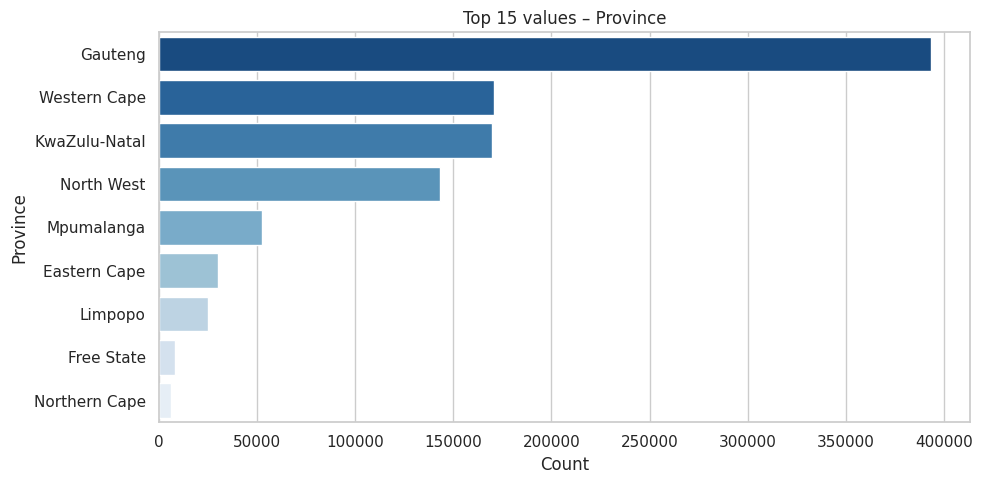

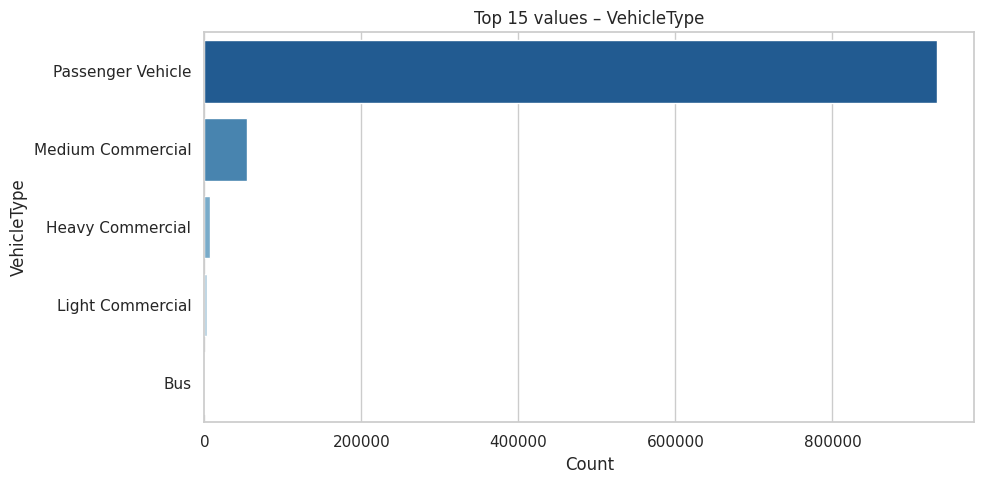

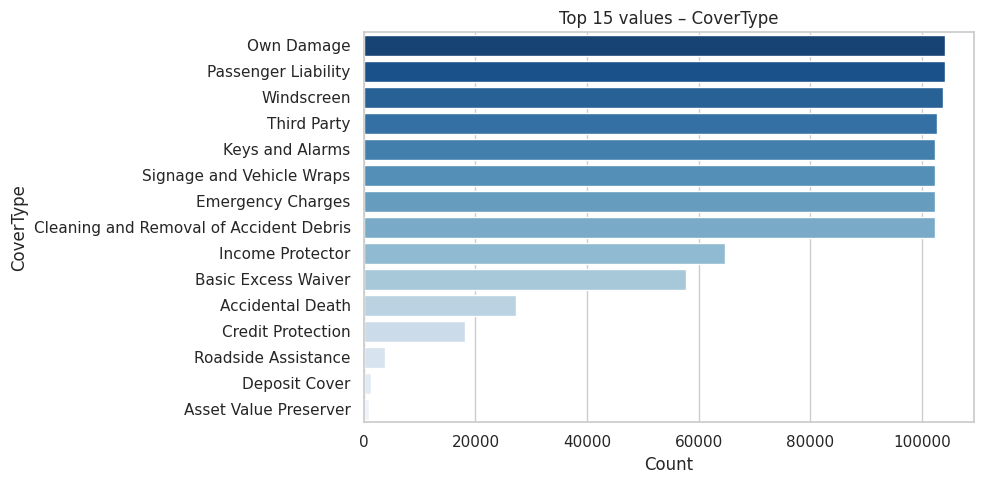

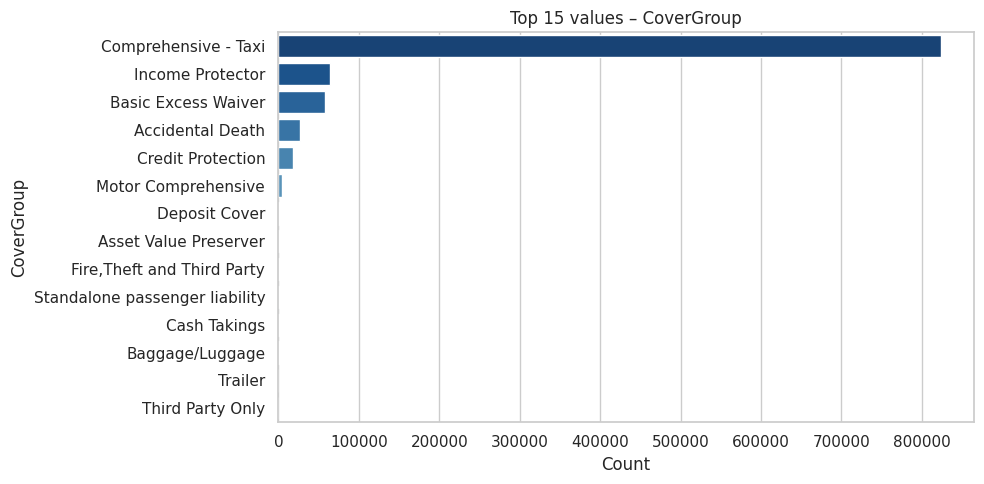

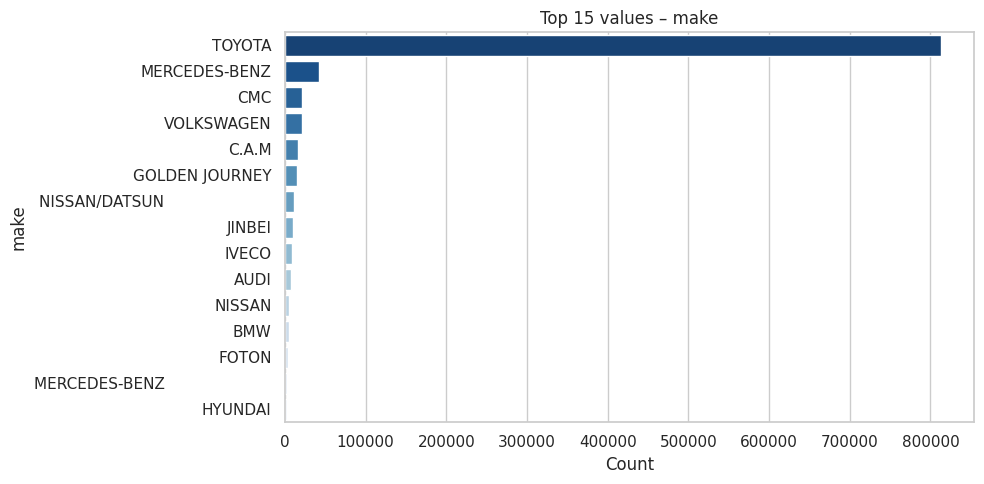

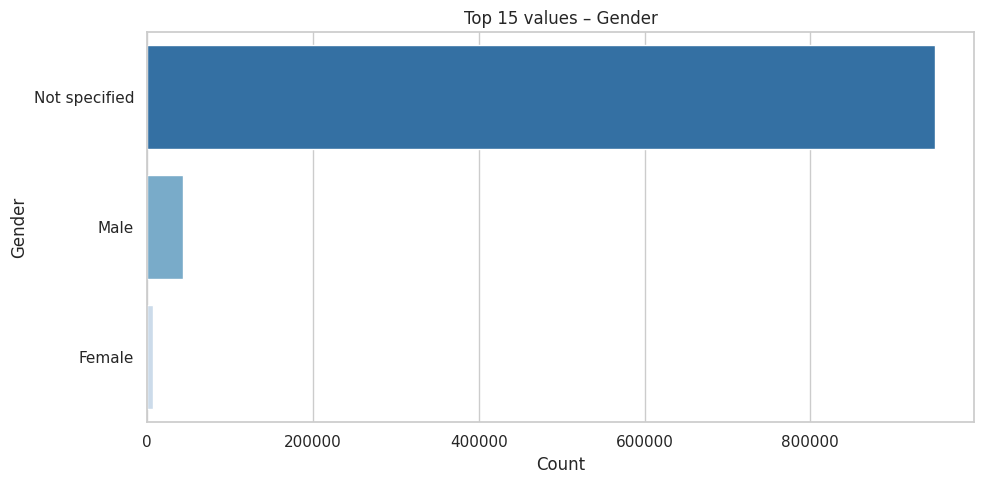

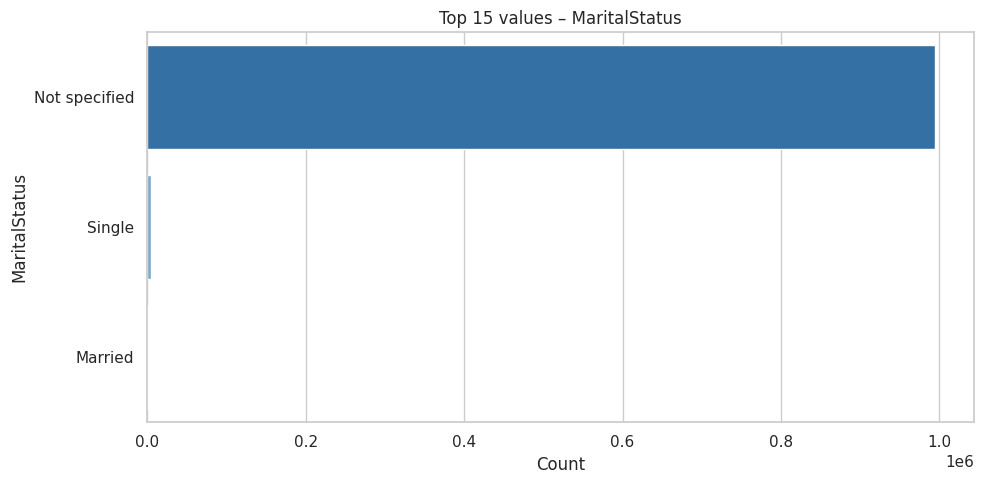

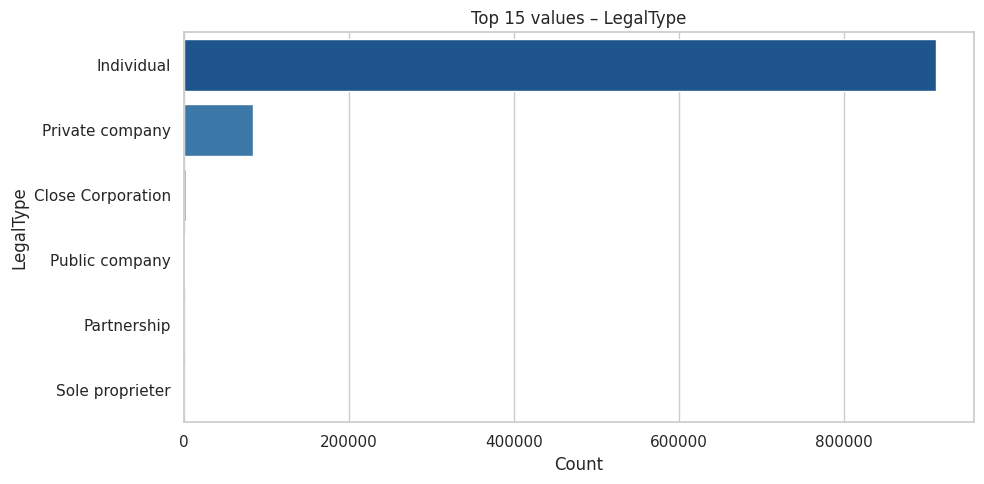

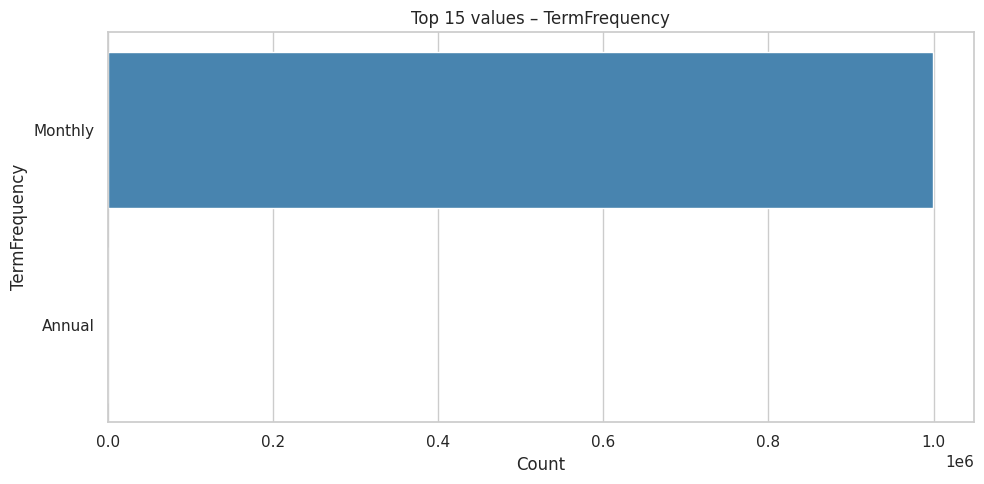

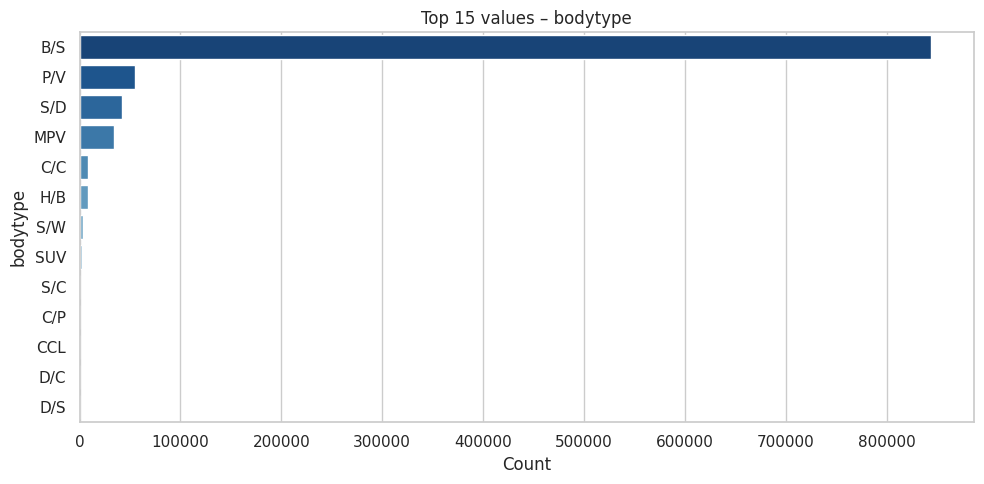

In [13]:
for col in ["Province", "VehicleType", "CoverType", "CoverGroup",
             "make", "Gender", "MaritalStatus", "LegalType",
             "TermFrequency", "bodytype"]:
    plot_categorical_counts(df_clean, col, top_n=15)
    plt.show()

---
## 5. Bivariate & Multivariate Analysis

### 5.1 TotalPremium vs TotalClaims by PostalCode

Scatter limited to rows where both values are positive; PostalCode used as colour dimension.

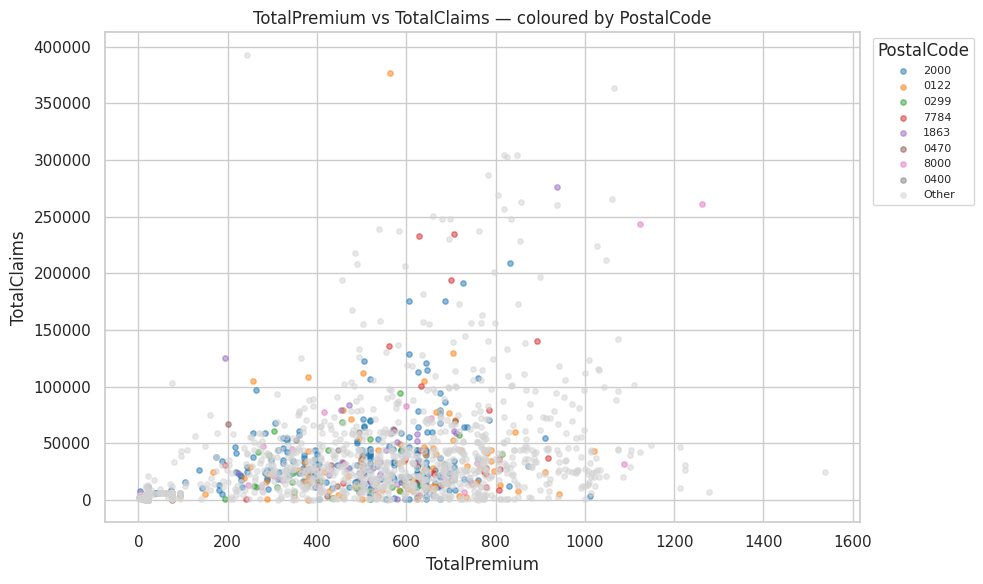

In [14]:
scatter_premium_vs_claims(df_clean, group_col="PostalCode", top_n=8, sample=25_000)
plt.show()

### 5.2 TotalPremium vs TotalClaims by Province

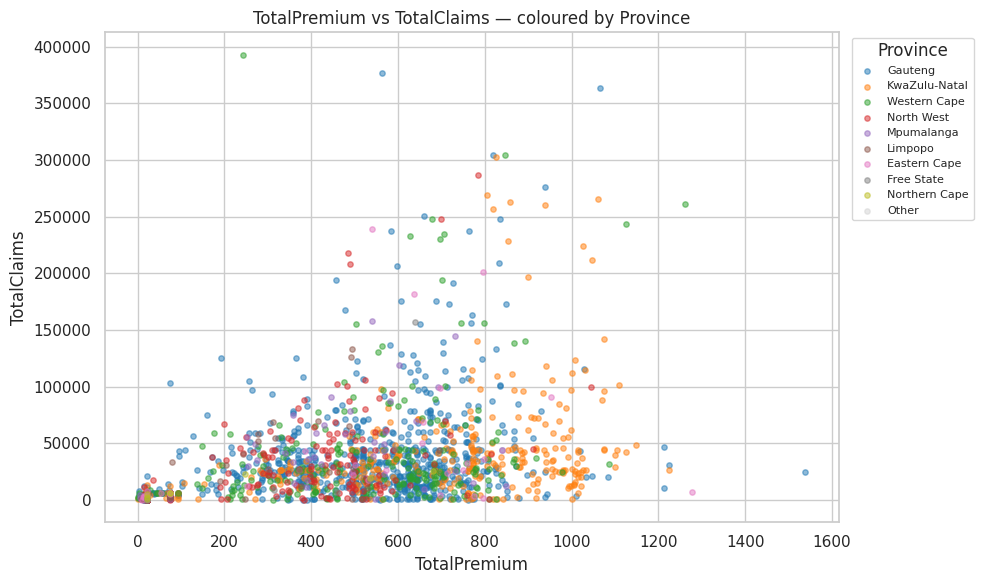

In [15]:
scatter_premium_vs_claims(df_clean, group_col="Province", top_n=9, sample=50_000)
plt.show()

### 5.3 Correlation Matrix — Key Numerical Features

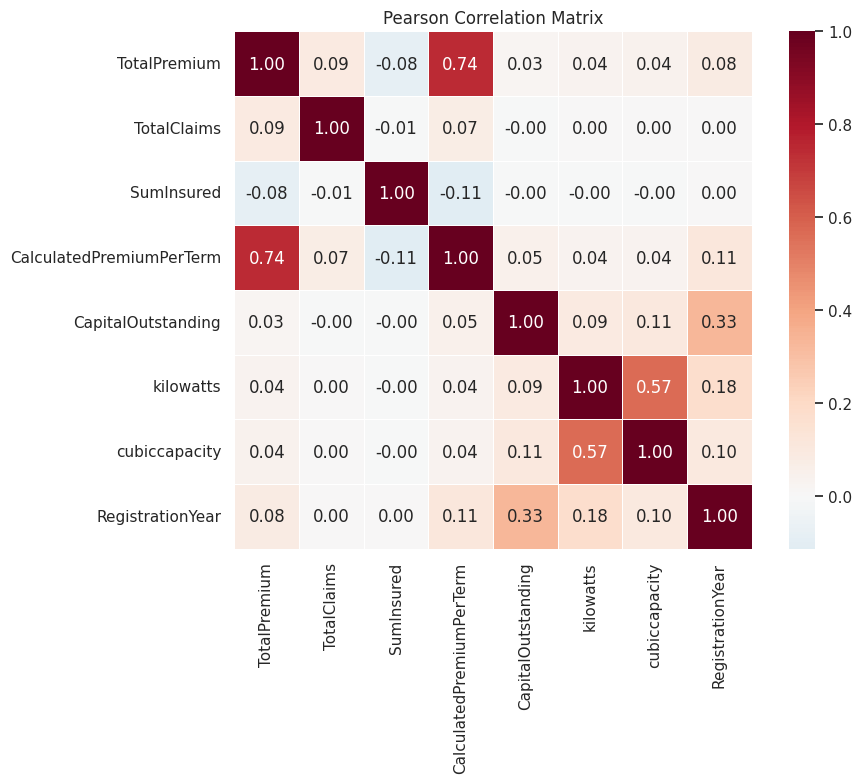

In [16]:
num_cols = ["TotalPremium", "TotalClaims", "SumInsured",
            "CalculatedPremiumPerTerm", "CapitalOutstanding",
            "kilowatts", "cubiccapacity", "RegistrationYear"]
correlation_heatmap(df_clean, num_cols)
plt.show()

### 5.4 Loss Ratio by Province & Cover Type

,Province,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Gauteng,24049006.3583,29394148.4768,393625,1.2223
1,KwaZulu-Natal,13209079.8122,14301382.4493,169781,1.0827
2,Western Cape,9244314.9723,9833087.7616,170562,1.0637
3,North West,7490508.1785,5920249.9951,143287,0.7904
4,Mpumalanga,2836105.5682,2044675.3579,52638,0.7209
5,Free State,521363.2450,354922.2719,8099,0.6808
6,Limpopo,1537324.4994,1016476.7105,24836,0.6612
7,Eastern Cape,2140103.8334,1356426.6639,30336,0.6338
8,Northern Cape,316558.0737,89490.5088,6380,0.2827


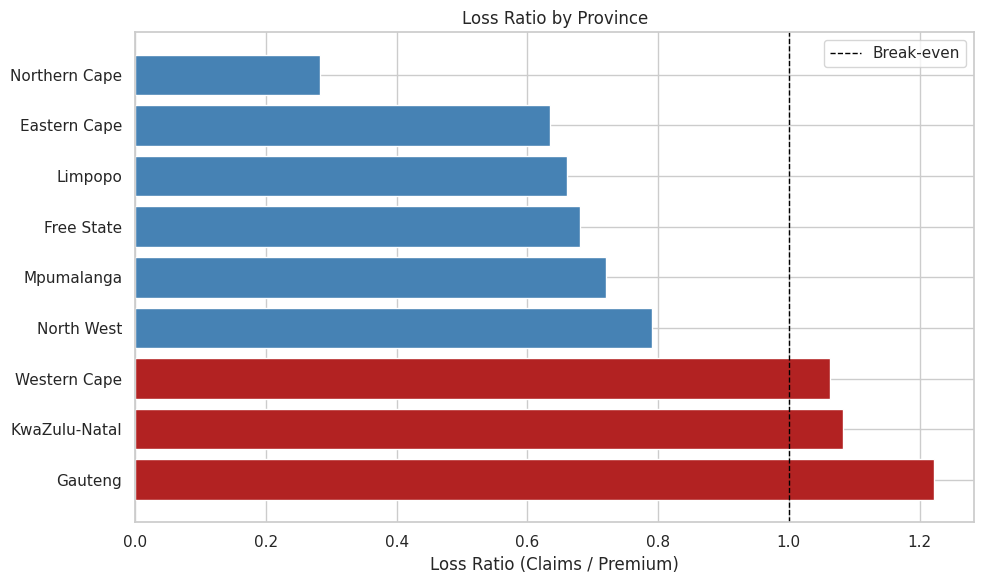

,VehicleType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Heavy Commercial,460947.8629,750474.5833,7401,1.6281
1,Medium Commercial,3922745.5524,4119866.9016,53985,1.0503
2,Passenger Vehicle,56641928.8656,59372069.6758,933596,1.0482
3,Light Commercial,260497.5204,60452.5000,3897,0.2321
4,Bus,58244.7397,7996.5351,665,0.1373


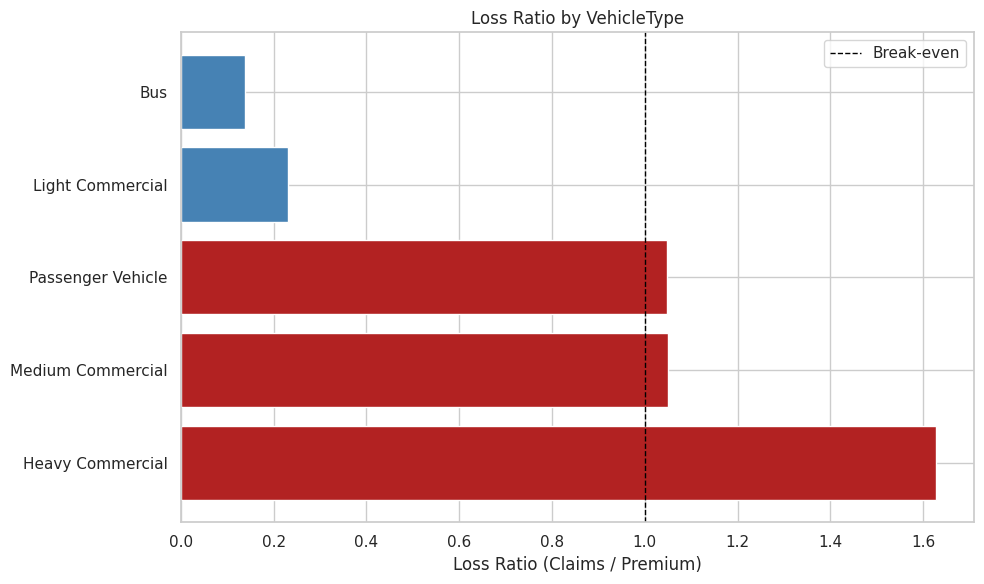

,CoverType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Factory Fitted Sound and Other Electronic Equi...,0.0000,21094.7368,3,inf
1,Own Damage,36856892.2554,58461830.7170,104120,1.5862
2,Windscreen,1288204.7559,1280177.0632,103700,0.9938
3,Income Protector,2972684.0805,2565458.7719,64789,0.8630
4,Deposit Cover,66835.3038,43859.6491,1299,0.6562
5,Credit Protection,1846776.4695,332589.3772,18070,0.1801
6,Third Party,13363445.6482,1578529.6140,102762,0.1181
7,Roadside Assistance,34485.8913,3344.0965,3834,0.0970
8,Emergency Charges,320749.5045,16410.3167,102353,0.0512
9,Keys and Alarms,213833.2164,7565.8533,102365,0.0354


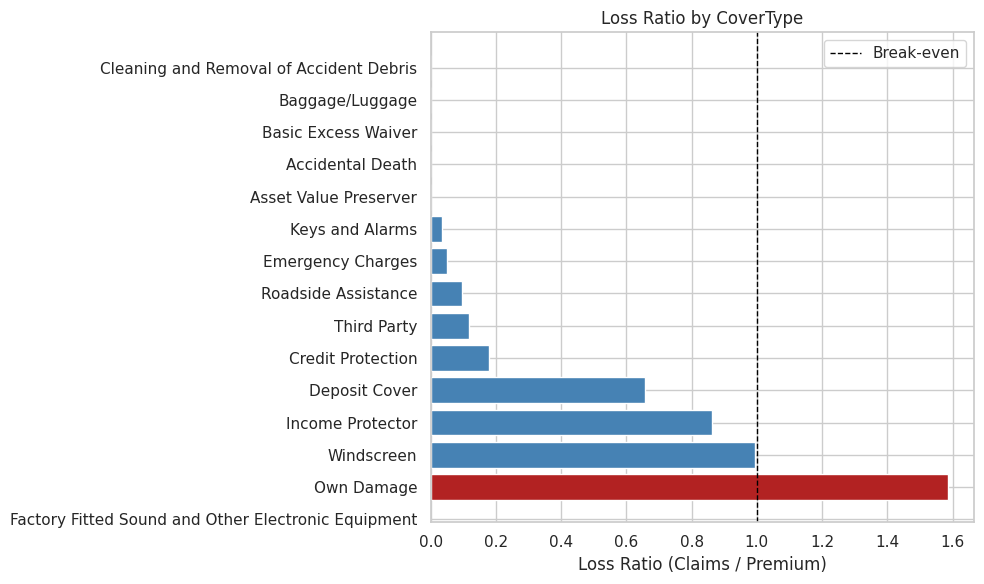

,make,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,SUZUKI,27012.5675,171210.8947,408,6.3382
1,JMC,5635.7863,23002.1754,120,4.0814
2,HYUNDAI,113615.5560,453307.9386,2602,3.9898
3,POLARSUN,41029.4020,125197.8433,934,3.0514
4,MARCOPOLO,2665.6514,7996.5351,51,2.9998
5,AUDI,376274.3198,1021003.7126,7407,2.7135
6,BMW,242765.2435,481497.1504,5317,1.9834
7,B.A.W,166044.0147,287137.4737,2160,1.7293
8,IVECO,526126.2385,755892.9518,8430,1.4367
9,CMC,957445.9996,1323615.5319,21624,1.3824


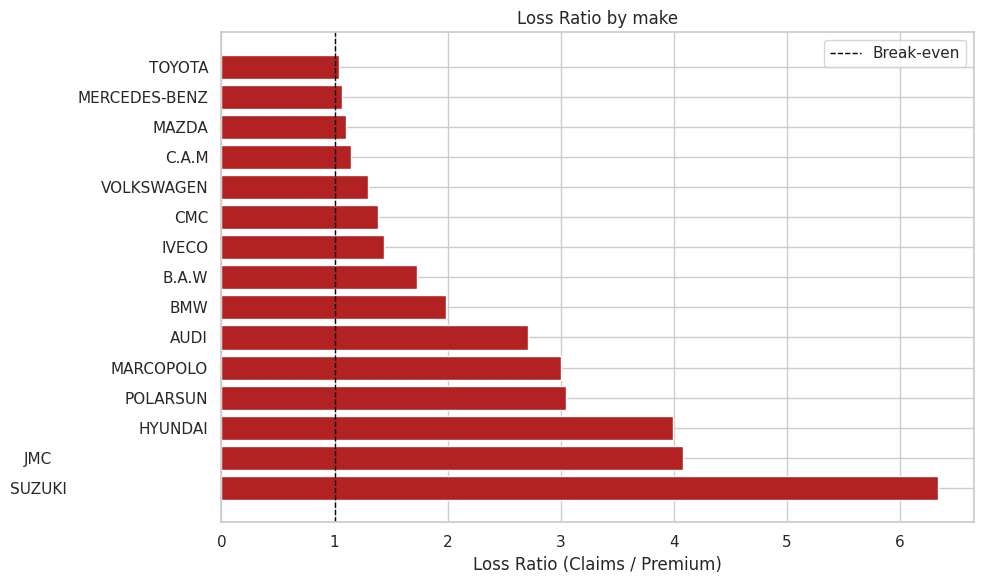

In [17]:
for dim in ["Province", "VehicleType", "CoverType", "make"]:
    display(loss_ratio_by_group(df_clean, dim).head(10))
    plot_loss_ratio_by_group(df_clean, dim, top_n=15)
    plt.show()

### 5.5 Monthly Trends — Premium & Claims

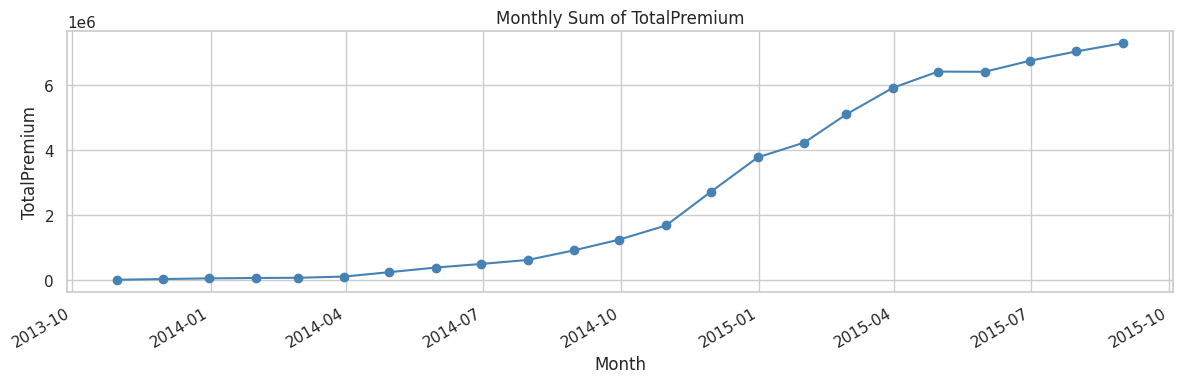

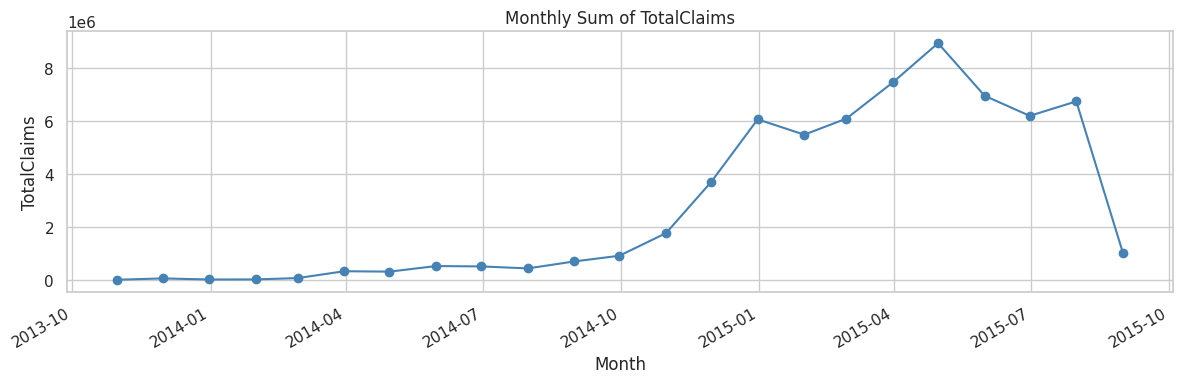

In [18]:
for col in ["TotalPremium", "TotalClaims"]:
    plot_monthly_trend(df_clean, col, agg="sum")
    plt.show()

---
## 6. Geographic Trends

### 6.1 Premium by Province

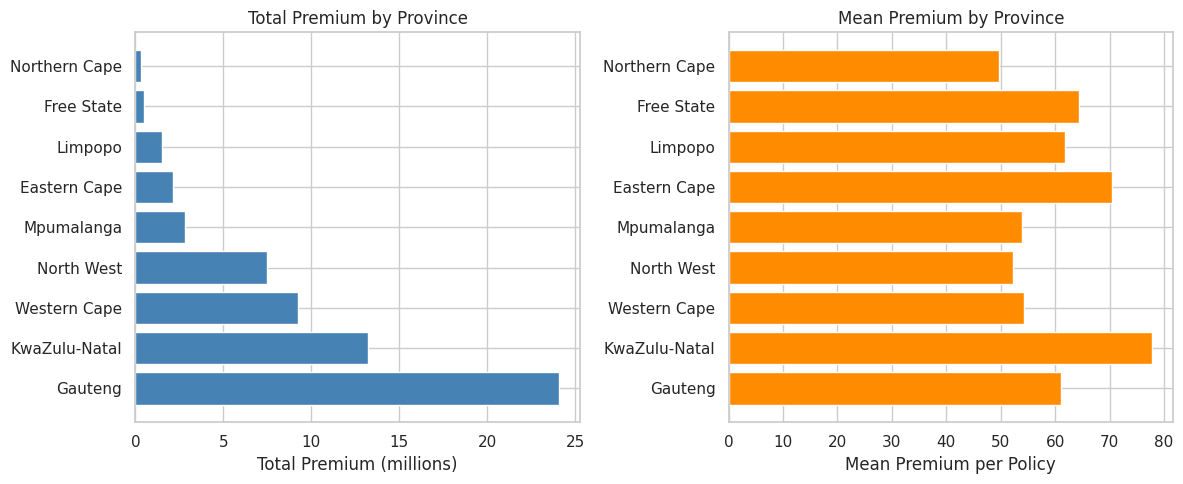

In [19]:
premium_by_province(df_clean)
plt.show()

### 6.2 Cover Type Mix by Province

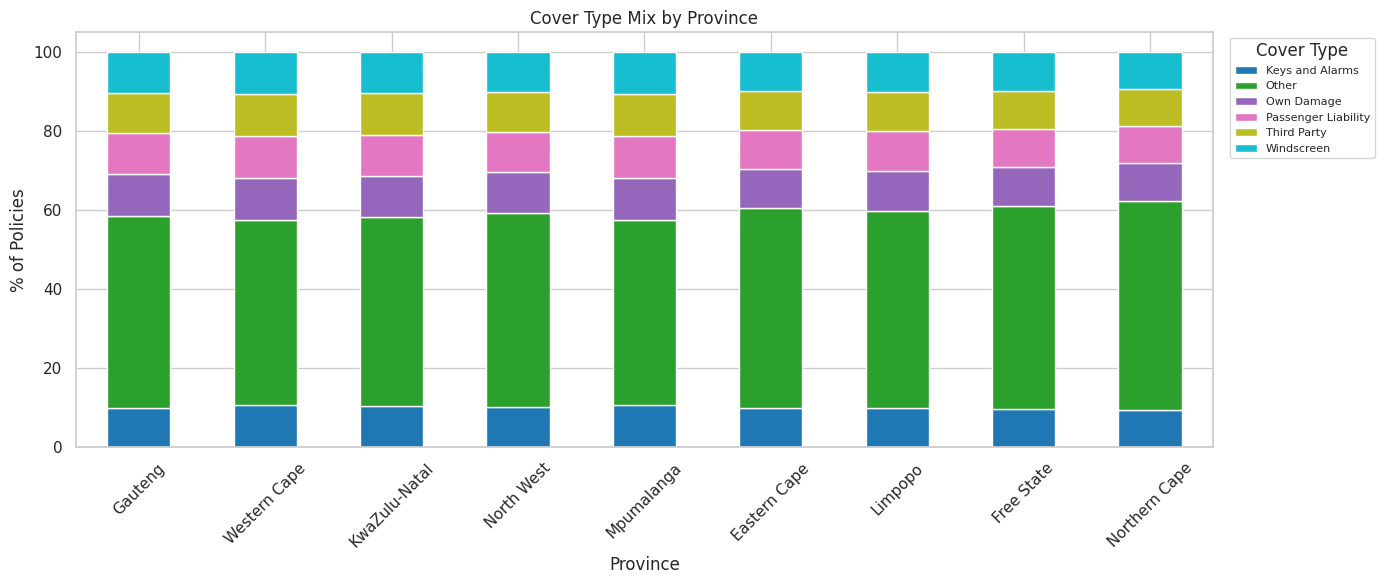

In [20]:
cover_type_by_province(df_clean, top_n=5)
plt.show()

### 6.3 Top Vehicle Makes by Province

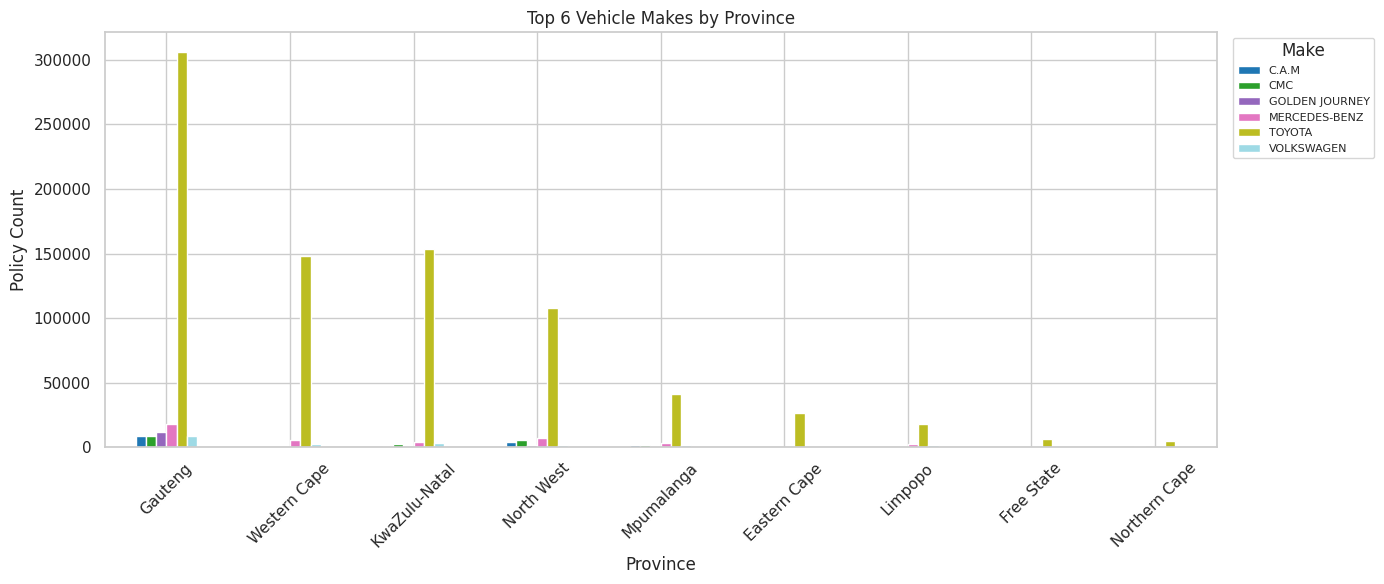

In [21]:
top_makes_by_province(df_clean, top_n=6)
plt.show()

### 6.4 Mean Premium Heatmap — Province × Cover Type

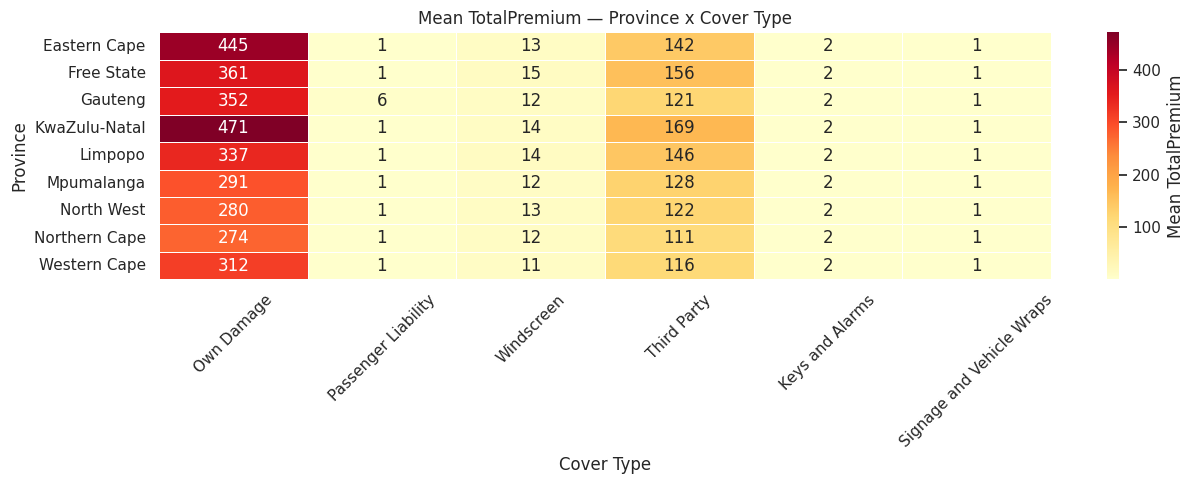

In [22]:
pivot = df_clean.groupby(["Province", "CoverType"], observed=True)["TotalPremium"].mean().unstack()
top_covers = df_clean["CoverType"].value_counts().head(6).index
pivot = pivot[top_covers]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean TotalPremium"})
ax.set_title("Mean TotalPremium — Province x Cover Type")
ax.set_xlabel("Cover Type")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 7. Outlier Detection

### 7.1 IQR-based Outlier Summary

In [23]:
key_cols = ["TotalPremium", "TotalClaims", "SumInsured",
            "CalculatedPremiumPerTerm", "CapitalOutstanding",
            "kilowatts", "cubiccapacity"]
outlier_summary(df_clean, key_cols)

,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_pct
column,,,,,,,
TotalPremium,0.0000,21.9298,21.9298,-32.8947,54.8246,208966,20.9100
TotalClaims,0.0000,0.0000,0.0000,0.0000,0.0000,2780,0.2800
SumInsured,5000.0000,250000.0000,245000.0000,-362500.0000,617500.0000,104200,10.4200
CalculatedPremiumPerTerm,3.2257,90.0000,86.7743,-126.9358,220.1614,175426,17.5500
CapitalOutstanding,0.0000,0.0000,0.0000,0.0000,0.0000,207316,20.7400
kilowatts,75.0000,111.0000,36.0000,21.0000,165.0000,2175,0.2200
cubiccapacity,2237.0000,2694.0000,457.0000,1551.5000,3379.5000,56939,5.7000


### 7.2 Box Plots — Raw Scale

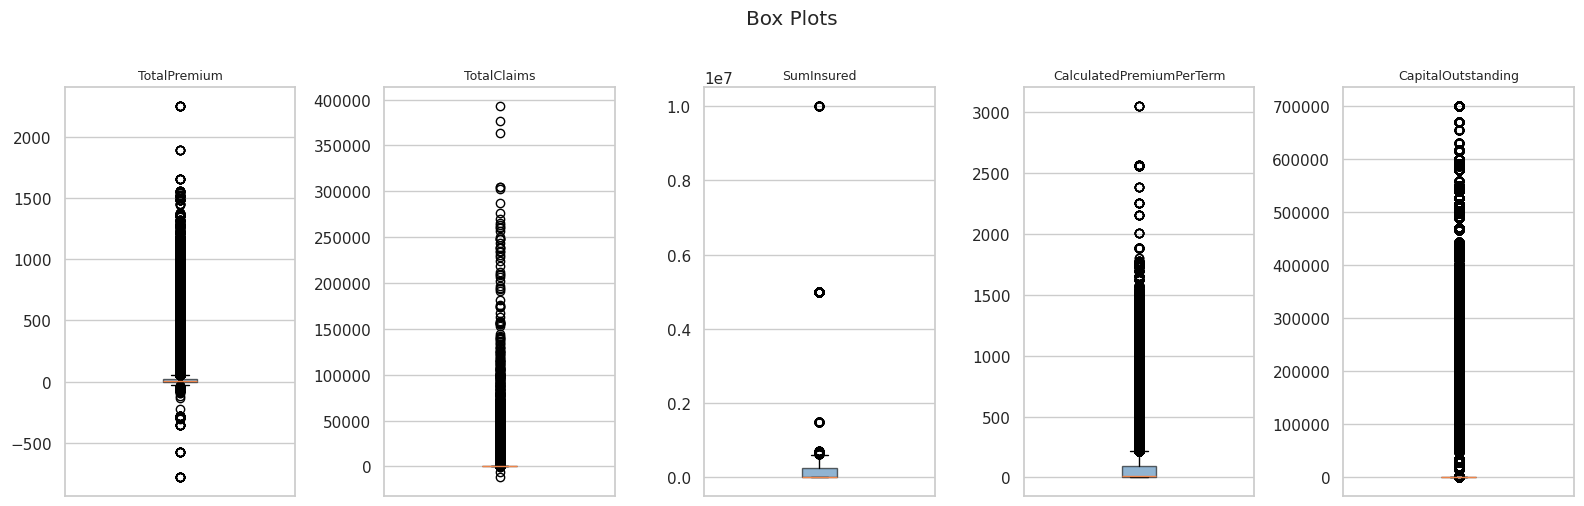

In [24]:
plot_boxplots(df_clean, ["TotalPremium", "TotalClaims", "SumInsured",
                          "CalculatedPremiumPerTerm", "CapitalOutstanding"],
              figsize=(16, 5))
plt.show()

### 7.3 Box Plots — Log Scale (to reveal spread within bounds)

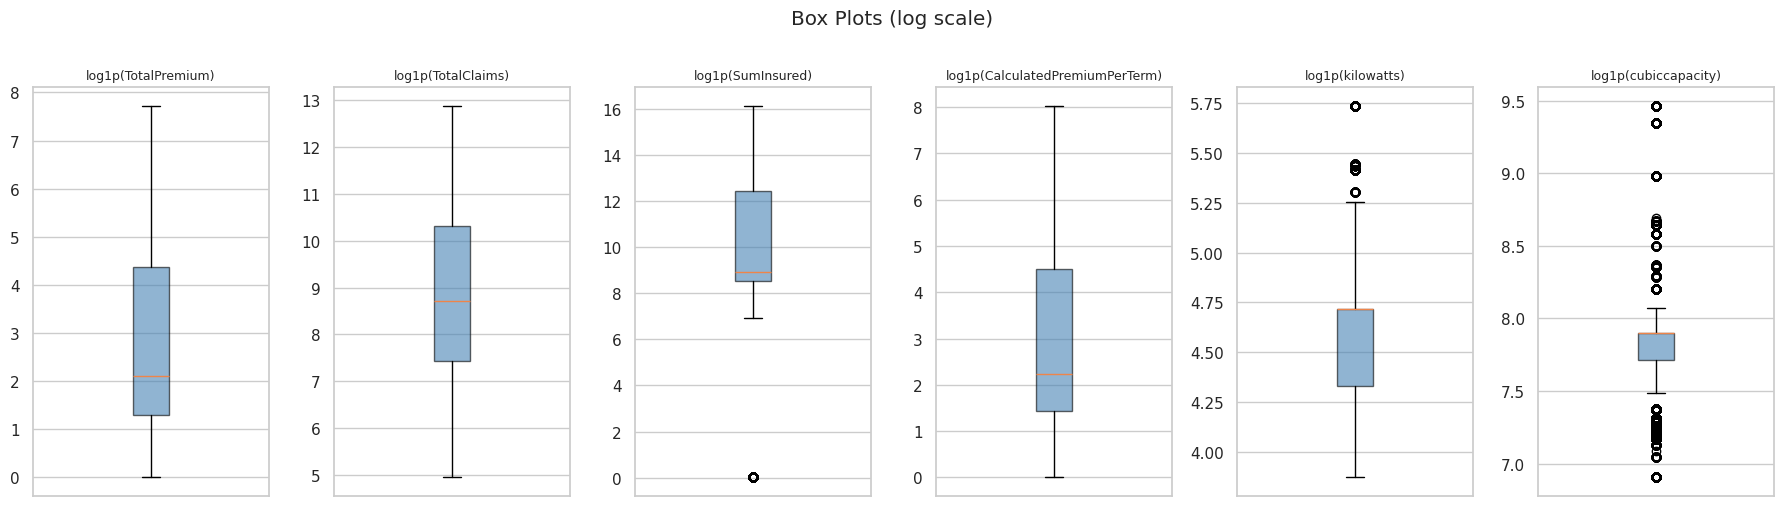

In [25]:
plot_boxplots(df_clean, ["TotalPremium", "TotalClaims", "SumInsured",
                          "CalculatedPremiumPerTerm", "kilowatts", "cubiccapacity"],
              log_scale=True, figsize=(18, 5))
plt.show()

### 7.4 Province-level Premium Outliers

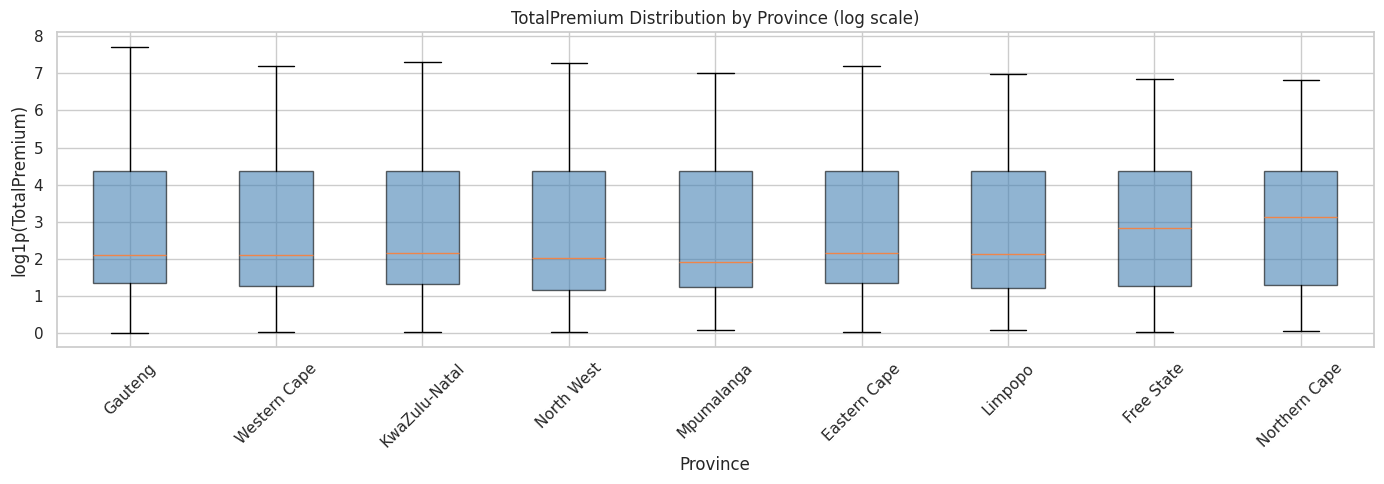

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
provinces = df_clean["Province"].value_counts().index.tolist()
data_by_prov = [np.log1p(df_clean.loc[df_clean["Province"] == p, "TotalPremium"]
                         .dropna().pipe(lambda s: s[s > 0]).values)
                for p in provinces]
ax.boxplot(data_by_prov, labels=provinces, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_xlabel("Province")
ax.set_ylabel("log1p(TotalPremium)")
ax.set_title("TotalPremium Distribution by Province (log scale)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 8. Key Findings Summary

| Area | Finding |
|---|---|
| **Zero-inflated claims** | 99.7% of policies have TotalClaims = 0; the remainder drive all loss exposure |
| **Zero premiums** | 38.2% of rows have TotalPremium = 0; these are add-on rows (e.g. Windscreen cover at R0) |
| **High-missing columns** | 7 columns dropped (100% or ~78% null); 4 columns imputed with mode/"Not specified" |
| **Dtype mismatches** | PostalCode & mmcode stored as object; VehicleIntroDate needs datetime parsing |
| **Extreme skewness** | TotalPremium skew ≈ 139, TotalClaims skew ≈ 70 — log1p transform required for modelling |
| **Overall loss ratio** | 1.05 — portfolio is marginally unprofitable at aggregate level |
| **Geographic risk** | Gauteng dominates policy count and total premium; provinces differ in cover mix |
| **Outliers** | SumInsured and CalculatedPremiumPerTerm have high outlier rates; clip or Winsorise before modelling |